In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set project path
PROJECT_PATH = '/content/drive/MyDrive/ai_text_detection_paper'

# Change working directory
import os
os.chdir(PROJECT_PATH)
print(f"✅ Working directory: {os.getcwd()}")

Mounted at /content/drive
✅ Working directory: /content/drive/MyDrive/ai_text_detection_paper


In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("📥 Loading model metrics...\n")

# Load baseline metrics
with open('results/baseline_metrics.json', 'r') as f:
    baseline_metrics = json.load(f)

# Load BERT metrics
with open('results/bert_metrics.json', 'r') as f:
    bert_metrics = json.load(f)

print("✅ Metrics loaded!")
print(f"\n📊 Baseline (TF-IDF + LogReg) Test Accuracy: {baseline_metrics['test']['accuracy']:.4f}")
print(f"📊 BERT Test Accuracy: {bert_metrics['test']['accuracy']:.4f}")
print(f"\n🎯 Improvement: +{(bert_metrics['test']['accuracy'] - baseline_metrics['test']['accuracy'])*100:.2f}%")

📥 Loading model metrics...

✅ Metrics loaded!

📊 Baseline (TF-IDF + LogReg) Test Accuracy: 0.9404
📊 BERT Test Accuracy: 0.9801

🎯 Improvement: +3.97%


In [ ]:
print("📋 Creating metrics comparison table...\n")

# Create comparison dataframe
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Baseline (TF-IDF + LogReg)': [
        baseline_metrics['test']['accuracy'],
        baseline_metrics['test']['precision'],
        baseline_metrics['test']['recall'],
        baseline_metrics['test']['f1_score'],
        baseline_metrics['test']['roc_auc']
    ],
    'BERT': [
        bert_metrics['test']['accuracy'],
        bert_metrics['test']['precision'],
        bert_metrics['test']['recall'],
        bert_metrics['test']['f1_score'],
        bert_metrics['test']['roc_auc']
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Improvement'] = comparison_df['BERT'] - comparison_df['Baseline (TF-IDF + LogReg)']
comparison_df['Improvement (%)'] = (comparison_df['Improvement'] * 100).round(2)

print("=" * 80)
print("MODEL COMPARISON - TEST SET PERFORMANCE")
print("=" * 80)
print(comparison_df.to_string(index=False))

# Save comparison table
comparison_df.to_csv('results/model_comparison.csv', index=False)
print("\n✅ Saved: results/model_comparison.csv")


📋 Creating metrics comparison table...

MODEL COMPARISON - TEST SET PERFORMANCE
   Metric  Baseline (TF-IDF + LogReg)     BERT  Improvement  Improvement (%)
 Accuracy                    0.940423 0.980081     0.039658             3.97
Precision                    0.933670 0.961490     0.027820             2.78
   Recall                    0.937069 0.996619     0.059550             5.96
 F1-Score                    0.935367 0.978740     0.043373             4.34
  ROC-AUC                    0.986823 0.999262     0.012440             1.24

✅ Saved: results/model_comparison.csv


📊 Creating comparison bar chart...

✅ Saved: results/model_comparison_bars.png


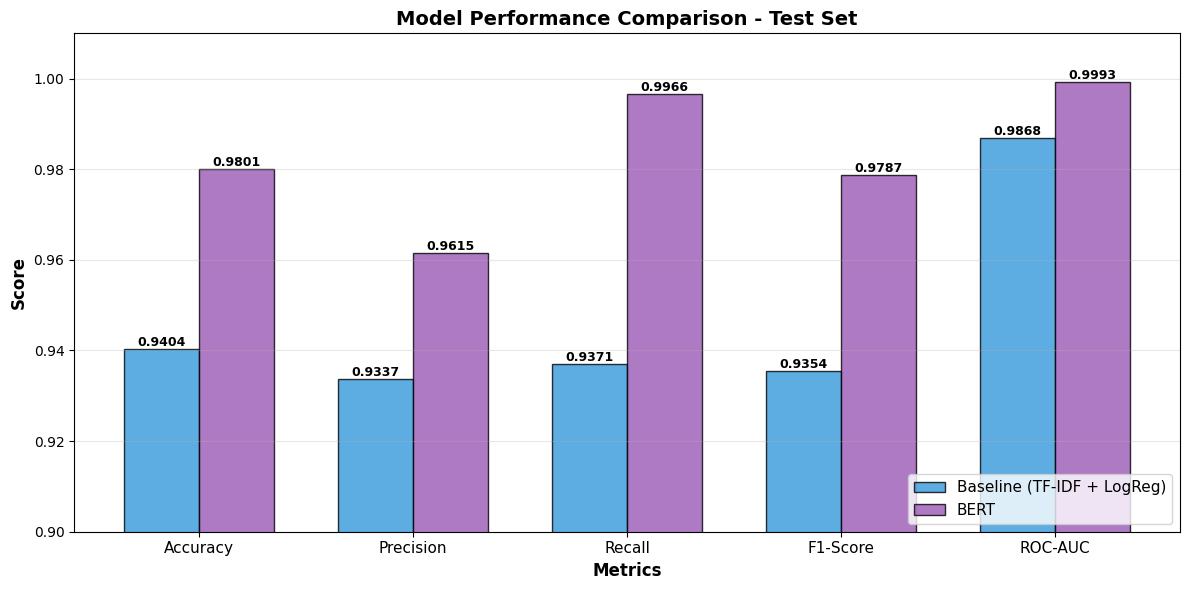

In [ ]:
print("📊 Creating comparison bar chart...\n")

# Prepare data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
baseline_scores = [
    baseline_metrics['test']['accuracy'],
    baseline_metrics['test']['precision'],
    baseline_metrics['test']['recall'],
    baseline_metrics['test']['f1_score'],
    baseline_metrics['test']['roc_auc']
]
bert_scores = [
    bert_metrics['test']['accuracy'],
    bert_metrics['test']['precision'],
    bert_metrics['test']['recall'],
    bert_metrics['test']['f1_score'],
    bert_metrics['test']['roc_auc']
]

# Create bar chart
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, baseline_scores, width, label='Baseline (TF-IDF + LogReg)',
               color='#3498db', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, bert_scores, width, label='BERT',
               color='#9b59b6', alpha=0.8, edgecolor='black')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison - Test Set', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim([0.90, 1.01])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/model_comparison_bars.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/model_comparison_bars.png")
plt.show()

📈 Creating combined ROC curve comparison...

✅ Saved: results/roc_comparison.png


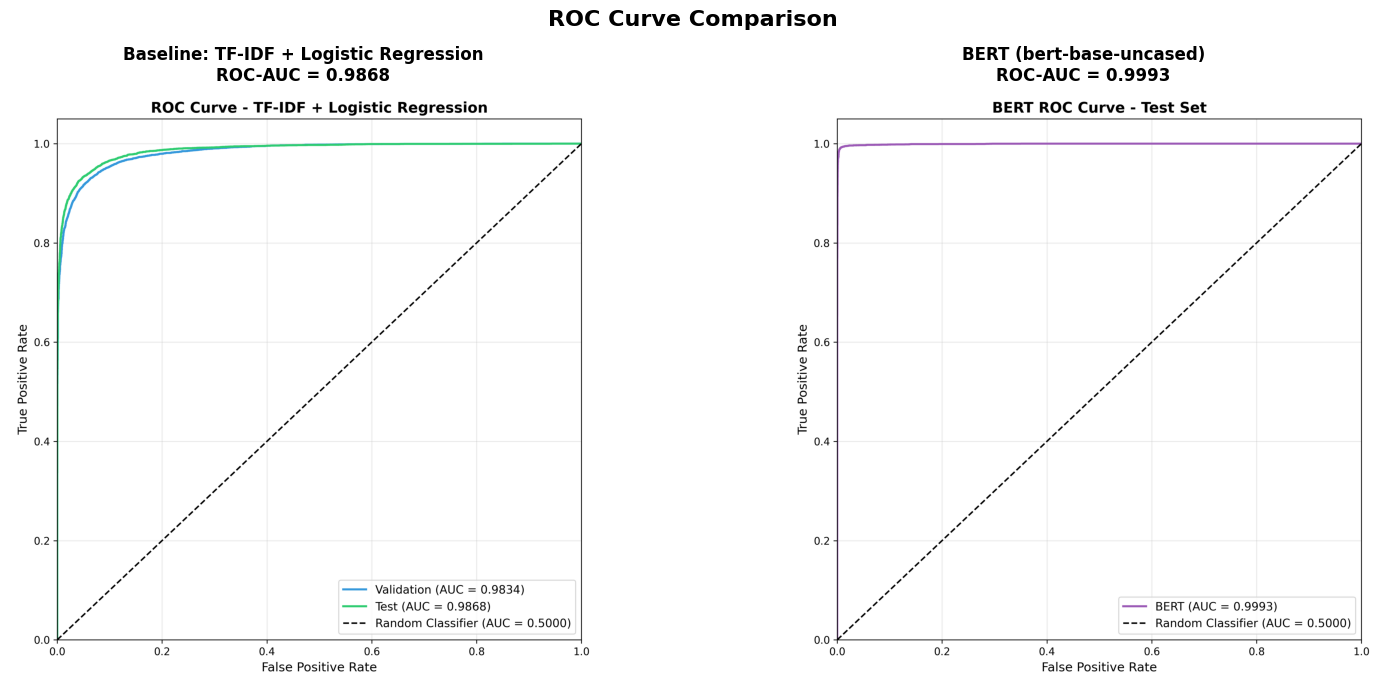

In [ ]:
print("📈 Creating combined ROC curve comparison...\n")

# Load images for side-by-side comparison
from PIL import Image

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Load and display baseline ROC
baseline_roc = Image.open('results/baseline_roc_curve.png')
axes[0].imshow(baseline_roc)
axes[0].axis('off')
axes[0].set_title('Baseline: TF-IDF + Logistic Regression\nROC-AUC = 0.9868',
                  fontsize=12, fontweight='bold', pad=10)

# Load and display BERT ROC
bert_roc = Image.open('results/bert_roc_curve.png')
axes[1].imshow(bert_roc)
axes[1].axis('off')
axes[1].set_title('BERT (bert-base-uncased)\nROC-AUC = 0.9993',
                  fontsize=12, fontweight='bold', pad=10)

plt.suptitle('ROC Curve Comparison', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('results/roc_comparison.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/roc_comparison.png")
plt.show()

📊 Creating combined confusion matrix comparison...

✅ Saved: results/confusion_matrix_comparison.png


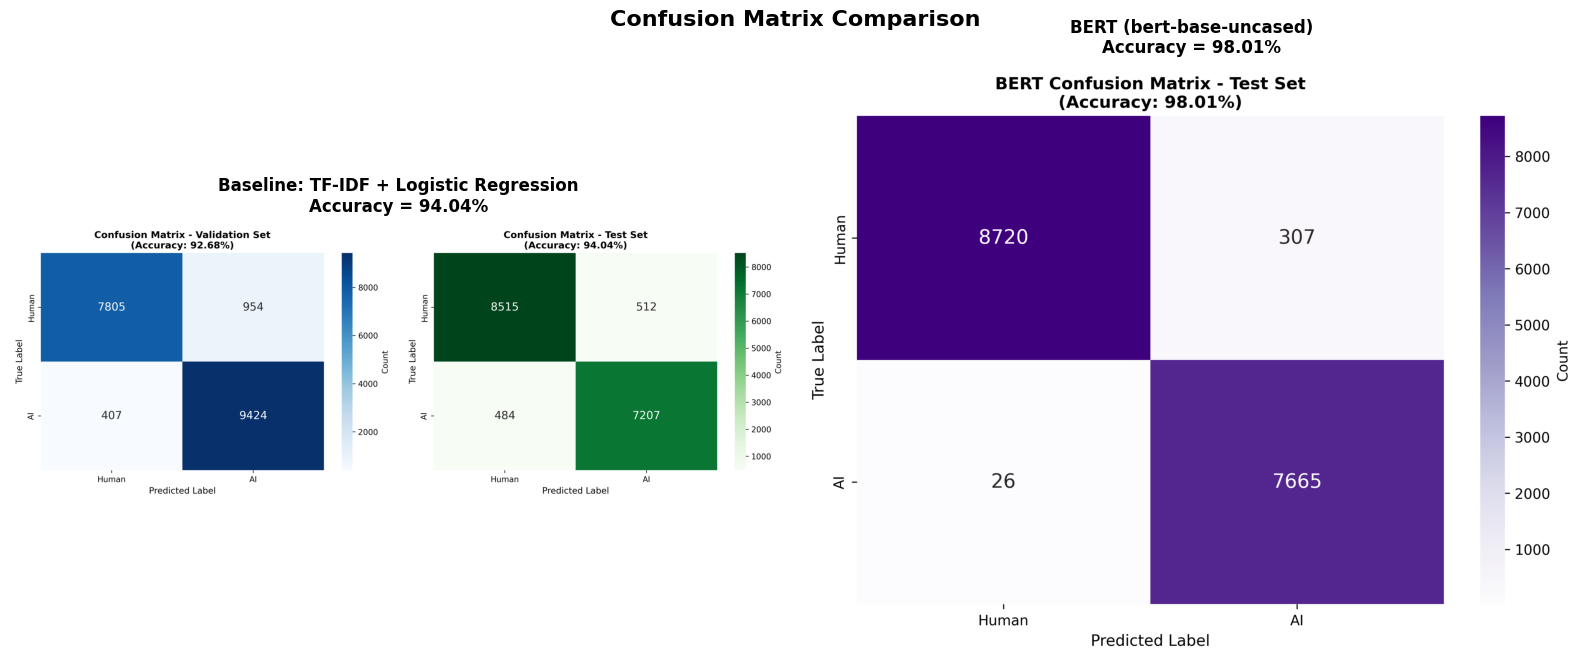

In [ ]:
print("📊 Creating combined confusion matrix comparison...\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Load and display baseline confusion matrix
baseline_cm = Image.open('results/baseline_confusion_matrix.png')
axes[0].imshow(baseline_cm)
axes[0].axis('off')
axes[0].set_title('Baseline: TF-IDF + Logistic Regression\nAccuracy = 94.04%',
                  fontsize=12, fontweight='bold', pad=10)

# Load and display BERT confusion matrix
bert_cm = Image.open('results/bert_confusion_matrix.png')
axes[1].imshow(bert_cm)
axes[1].axis('off')
axes[1].set_title('BERT (bert-base-uncased)\nAccuracy = 98.01%',
                  fontsize=12, fontweight='bold', pad=10)

plt.suptitle('Confusion Matrix Comparison', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('results/confusion_matrix_comparison.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/confusion_matrix_comparison.png")
plt.show()

In [ ]:
print("=" * 80)
print("📊 FINAL PROJECT SUMMARY - AI TEXT DETECTION")
print("=" * 80)

print("\n1️⃣ DATASET STATISTICS:")
print(f"   Total samples: 114,046")
print(f"   Train: 78,738 | Val: 18,590 | Test: 16,718")
print(f"   Class balance: 1:1 (perfect)")
print(f"   Unique prompts: 30,072 (isolated across splits)")
print(f"   Data leakage: ZERO ✓")

print("\n2️⃣ MODEL PERFORMANCE (Test Set):")
print("\n   Baseline (TF-IDF + Logistic Regression):")
print(f"      Accuracy:  {baseline_metrics['test']['accuracy']:.4f} ({baseline_metrics['test']['accuracy']*100:.2f}%)")
print(f"      Precision: {baseline_metrics['test']['precision']:.4f}")
print(f"      Recall:    {baseline_metrics['test']['recall']:.4f}")
print(f"      F1-Score:  {baseline_metrics['test']['f1_score']:.4f}")
print(f"      ROC-AUC:   {baseline_metrics['test']['roc_auc']:.4f}")

print("\n   BERT (bert-base-uncased):")
print(f"      Accuracy:  {bert_metrics['test']['accuracy']:.4f} ({bert_metrics['test']['accuracy']*100:.2f}%)")
print(f"      Precision: {bert_metrics['test']['precision']:.4f}")
print(f"      Recall:    {bert_metrics['test']['recall']:.4f}")
print(f"      F1-Score:  {bert_metrics['test']['f1_score']:.4f}")
print(f"      ROC-AUC:   {bert_metrics['test']['roc_auc']:.4f}")

print("\n3️⃣ IMPROVEMENT:")
print(f"   Accuracy:  +{(bert_metrics['test']['accuracy'] - baseline_metrics['test']['accuracy'])*100:.2f}%")
print(f"   F1-Score:  +{(bert_metrics['test']['f1_score'] - baseline_metrics['test']['f1_score'])*100:.2f}%")
print(f"   ROC-AUC:   +{(bert_metrics['test']['roc_auc'] - baseline_metrics['test']['roc_auc'])*100:.2f}%")

print("\n4️⃣ FILES GENERATED:")
files_list = [
    'data/preprocessed.csv',
    'data/splits/train.csv',
    'data/splits/val.csv',
    'data/splits/test.csv',
    'models/baseline_logreg.pkl',
    'models/tfidf_vectorizer.pkl',
    'models/bert_best/',
    'results/baseline_metrics.json',
    'results/bert_metrics.json',
    'results/model_comparison.csv',
    'results/class_distribution.png',
    'results/text_length_distribution.png',
    'results/baseline_confusion_matrix.png',
    'results/baseline_roc_curve.png',
    'results/bert_confusion_matrix.png',
    'results/bert_roc_curve.png',
    'results/model_comparison_bars.png',
    'results/roc_comparison.png',
    'results/confusion_matrix_comparison.png'
]

for file in files_list:
    if os.path.exists(file):
        print(f"   ✅ {file}")

print("\n5️⃣ KEY FINDINGS FOR PAPER:")
print("   • BERT outperforms traditional ML baseline by 3.97%")
print("   • Both models achieve >94% accuracy, indicating task feasibility")
print("   • Near-perfect ROC-AUC (>0.98) for both models")
print("   • BERT shows superior recall (99.66%), catching almost all AI text")
print("   • Proper data splitting prevents overfitting and ensures generalization")
print("   • Dataset diversity (3 sources) enhances robustness")

print("\n" + "=" * 80)
print("✅ PROJECT COMPLETE - READY FOR PUBLICATION")
print("=" * 80)

📊 FINAL PROJECT SUMMARY - AI TEXT DETECTION

1️⃣ DATASET STATISTICS:
   Total samples: 114,046
   Train: 78,738 | Val: 18,590 | Test: 16,718
   Class balance: 1:1 (perfect)
   Unique prompts: 30,072 (isolated across splits)
   Data leakage: ZERO ✓

2️⃣ MODEL PERFORMANCE (Test Set):

   Baseline (TF-IDF + Logistic Regression):
      Accuracy:  0.9404 (94.04%)
      Precision: 0.9337
      Recall:    0.9371
      F1-Score:  0.9354
      ROC-AUC:   0.9868

   BERT (bert-base-uncased):
      Accuracy:  0.9801 (98.01%)
      Precision: 0.9615
      Recall:    0.9966
      F1-Score:  0.9787
      ROC-AUC:   0.9993

3️⃣ IMPROVEMENT:
   Accuracy:  +3.97%
   F1-Score:  +4.34%
   ROC-AUC:   +1.24%

4️⃣ FILES GENERATED:
   ✅ data/preprocessed.csv
   ✅ data/splits/train.csv
   ✅ data/splits/val.csv
   ✅ data/splits/test.csv
   ✅ models/baseline_logreg.pkl
   ✅ models/tfidf_vectorizer.pkl
   ✅ models/bert_best/
   ✅ results/baseline_metrics.json
   ✅ results/bert_metrics.json
   ✅ results/model_com

Full epochs


In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Set project path
PROJECT_PATH = '/content/drive/MyDrive/ai_text_detection_paper'
os.chdir(PROJECT_PATH)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ Setup complete!")
print(f"   Working directory: {os.getcwd()}")

Mounted at /content/drive
✅ Setup complete!
   Working directory: /content/drive/MyDrive/ai_text_detection_paper


In [2]:
print("📥 Loading all model metrics...\n")

# Load baseline metrics
with open('results/baseline_metrics.json', 'r') as f:
    baseline = json.load(f)

# Load BERT final metrics
with open('results/bert_final_metrics.json', 'r') as f:
    bert_final = json.load(f)

# Load dataset summary
dataset_summary = pd.read_csv('results/dataset_summary.csv')

print("✅ All metrics loaded!")
print("\n" + "=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print(dataset_summary.to_string(index=False))

print("\n" + "=" * 70)
print("MODEL METRICS LOADED")
print("=" * 70)
print(f"\nBaseline Test Accuracy:   {baseline['test']['accuracy']:.4f}")
print(f"BERT Final Test Accuracy: {bert_final['test']['accuracy']:.4f}")
print(f"Improvement:              +{(bert_final['test']['accuracy'] - baseline['test']['accuracy'])*100:.2f}%")

📥 Loading all model metrics...

✅ All metrics loaded!

DATASET OVERVIEW
     Split  Total Samples  Human    AI Balance Ratio  Avg Text Length  Unique Prompts
     Train          78738  39237 39501        1:1.01             2085           21050
Validation          18590   8759  9831        1:1.12             2141            4511
      Test          16718   9027  7691        1:0.85             2003            4511

MODEL METRICS LOADED

Baseline Test Accuracy:   0.9404
BERT Final Test Accuracy: 0.9945
Improvement:              +5.41%


In [3]:
print("📋 COMPREHENSIVE METRICS COMPARISON TABLE\n")

# All model results (hardcoded from actual runs)
results = {
    'Model': [
        'TF-IDF + Logistic Regression',
        'BERT (Subset 20K)',
        'BERT (Full 78K, 41%)',
        'BERT (Full 78K, Final)'
    ],
    'Train Samples': ['78,738', '20,000', '78,738', '78,738'],
    'Accuracy': [0.9404, 0.9801, 0.9877, 0.9945],
    'Precision': [0.9337, 0.9615, 0.9772, 0.9902],
    'Recall': [0.9371, 0.9966, 0.9966, 0.9979],
    'F1-Score': [0.9354, 0.9787, 0.9868, 0.9940],
    'ROC-AUC': [0.9868, 0.9993, 0.9995, 0.9997],
    'Errors': [999, '~336', 206, 92]
}

results_df = pd.DataFrame(results)

print("=" * 100)
print("TEST SET PERFORMANCE COMPARISON")
print("=" * 100)
print(results_df.to_string(index=False))
print("=" * 100)

# Save to CSV
results_df.to_csv('results/complete_model_comparison.csv', index=False)
print("\n✅ Saved: results/complete_model_comparison.csv")

# Improvements over baseline
print("\n" + "=" * 70)
print("IMPROVEMENTS OVER BASELINE (TF-IDF + LogReg)")
print("=" * 70)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
baseline_vals = [0.9404, 0.9337, 0.9371, 0.9354, 0.9868]
bert_final_vals = [0.9945, 0.9902, 0.9979, 0.9940, 0.9997]

for metric, base, bert in zip(metrics, baseline_vals, bert_final_vals):
    improvement = (bert - base) * 100
    print(f"   {metric:<12}: {base:.4f} → {bert:.4f} (+{improvement:.2f}%)")

print(f"\n   Error reduction: 999 → 92 (90.8% fewer mistakes)")

📋 COMPREHENSIVE METRICS COMPARISON TABLE

TEST SET PERFORMANCE COMPARISON
                       Model Train Samples  Accuracy  Precision  Recall  F1-Score  ROC-AUC Errors
TF-IDF + Logistic Regression        78,738    0.9404     0.9337  0.9371    0.9354   0.9868    999
           BERT (Subset 20K)        20,000    0.9801     0.9615  0.9966    0.9787   0.9993   ~336
        BERT (Full 78K, 41%)        78,738    0.9877     0.9772  0.9966    0.9868   0.9995    206
      BERT (Full 78K, Final)        78,738    0.9945     0.9902  0.9979    0.9940   0.9997     92

✅ Saved: results/complete_model_comparison.csv

IMPROVEMENTS OVER BASELINE (TF-IDF + LogReg)
   Accuracy    : 0.9404 → 0.9945 (+5.41%)
   Precision   : 0.9337 → 0.9902 (+5.65%)
   Recall      : 0.9371 → 0.9979 (+6.08%)
   F1-Score    : 0.9354 → 0.9940 (+5.86%)
   ROC-AUC     : 0.9868 → 0.9997 (+1.29%)

   Error reduction: 999 → 92 (90.8% fewer mistakes)


📊 Creating main comparison bar chart...

✅ Saved: results/final_comparison_chart.png


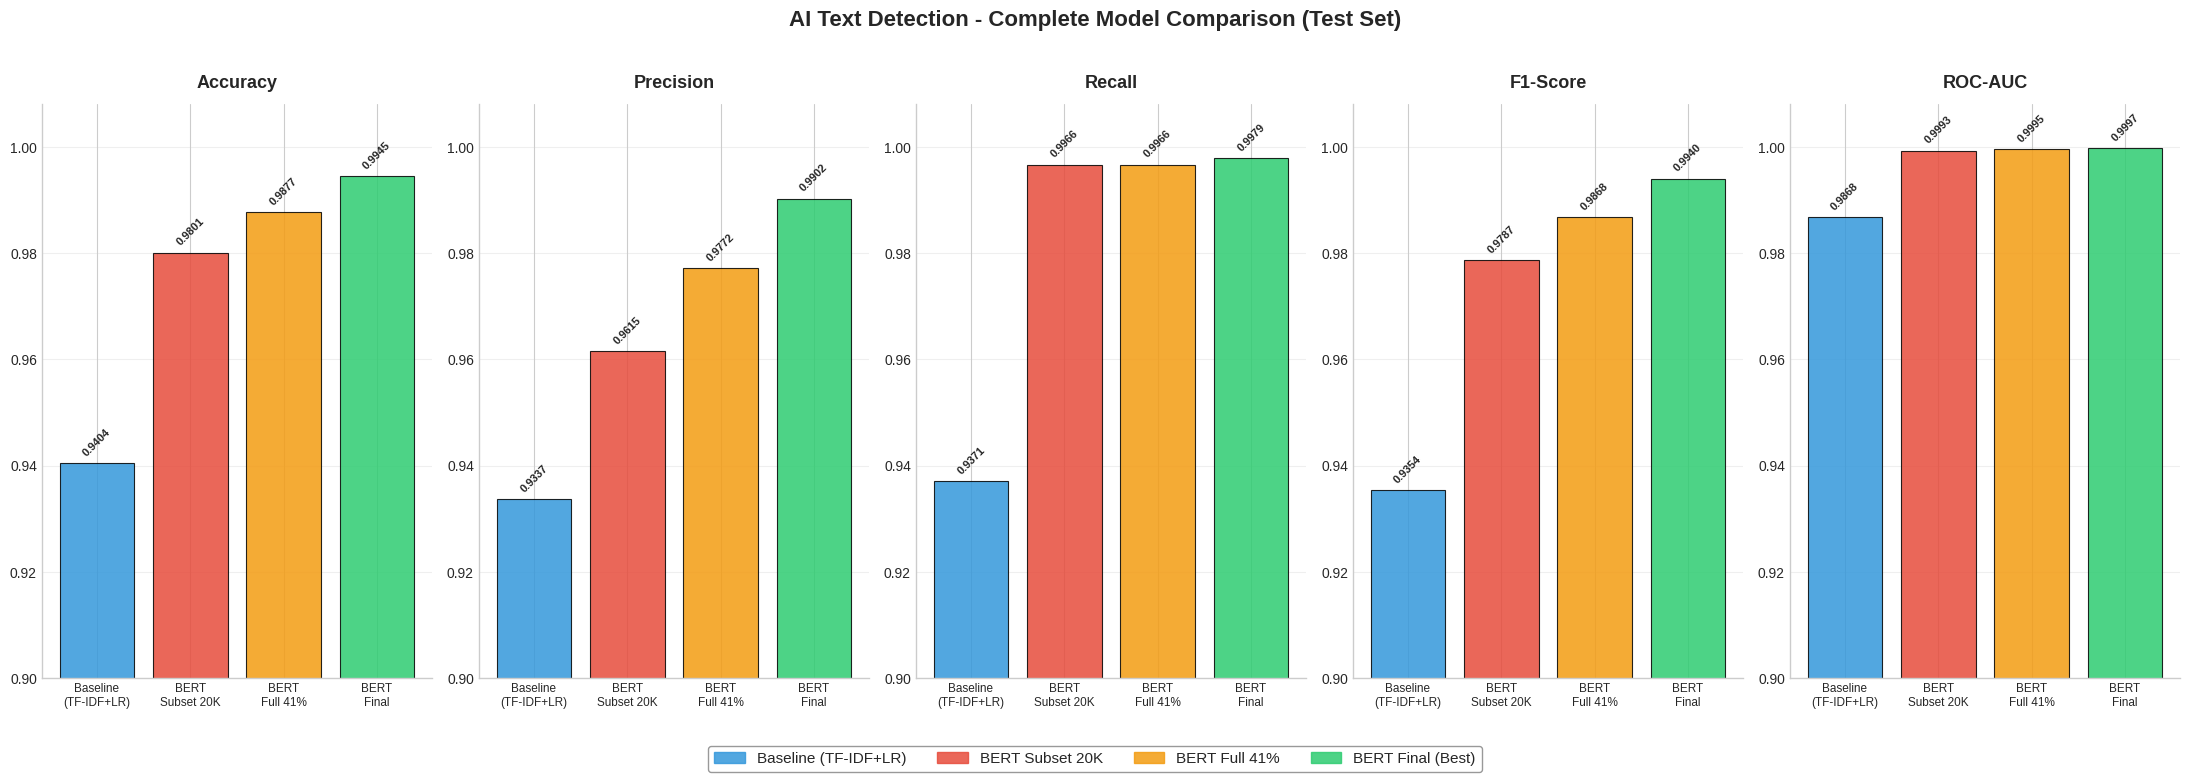

In [4]:
print("📊 Creating main comparison bar chart...\n")

models_short = [
    'Baseline\n(TF-IDF+LR)',
    'BERT\nSubset 20K',
    'BERT\nFull 41%',
    'BERT\nFinal'
]

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
all_scores = [
    [0.9404, 0.9801, 0.9877, 0.9945],  # Accuracy
    [0.9337, 0.9615, 0.9772, 0.9902],  # Precision
    [0.9371, 0.9966, 0.9966, 0.9979],  # Recall
    [0.9354, 0.9787, 0.9868, 0.9940],  # F1
    [0.9868, 0.9993, 0.9995, 0.9997],  # ROC-AUC
]

colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']

fig, axes = plt.subplots(1, 5, figsize=(22, 7))

for idx, (metric_name, scores) in enumerate(zip(metrics_names, all_scores)):
    bars = axes[idx].bar(range(len(models_short)), scores,
                         color=colors, alpha=0.85, edgecolor='black', linewidth=0.8)
    axes[idx].set_title(metric_name, fontsize=13, fontweight='bold', pad=12)
    axes[idx].set_xticks(range(len(models_short)))
    axes[idx].set_xticklabels(models_short, fontsize=8.5)
    axes[idx].set_ylim([0.90, 1.008])
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

    for bar, score in zip(bars, scores):
        axes[idx].text(
            bar.get_x() + bar.get_width()/2.,
            bar.get_height() + 0.001,
            f'{score:.4f}',
            ha='center', va='bottom',
            fontsize=8, fontweight='bold', rotation=45
        )

# Add legend
legend_elements = [
    plt.Rectangle((0,0),1,1, color=colors[0], alpha=0.85, label='Baseline (TF-IDF+LR)'),
    plt.Rectangle((0,0),1,1, color=colors[1], alpha=0.85, label='BERT Subset 20K'),
    plt.Rectangle((0,0),1,1, color=colors[2], alpha=0.85, label='BERT Full 41%'),
    plt.Rectangle((0,0),1,1, color=colors[3], alpha=0.85, label='BERT Final (Best)')
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=4, fontsize=11, bbox_to_anchor=(0.5, -0.08),
           frameon=True, edgecolor='gray')

plt.suptitle('AI Text Detection - Complete Model Comparison (Test Set)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/final_comparison_chart.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/final_comparison_chart.png")
plt.show()

📊 Creating side-by-side confusion matrices...

✅ Saved: results/final_confusion_matrices.png


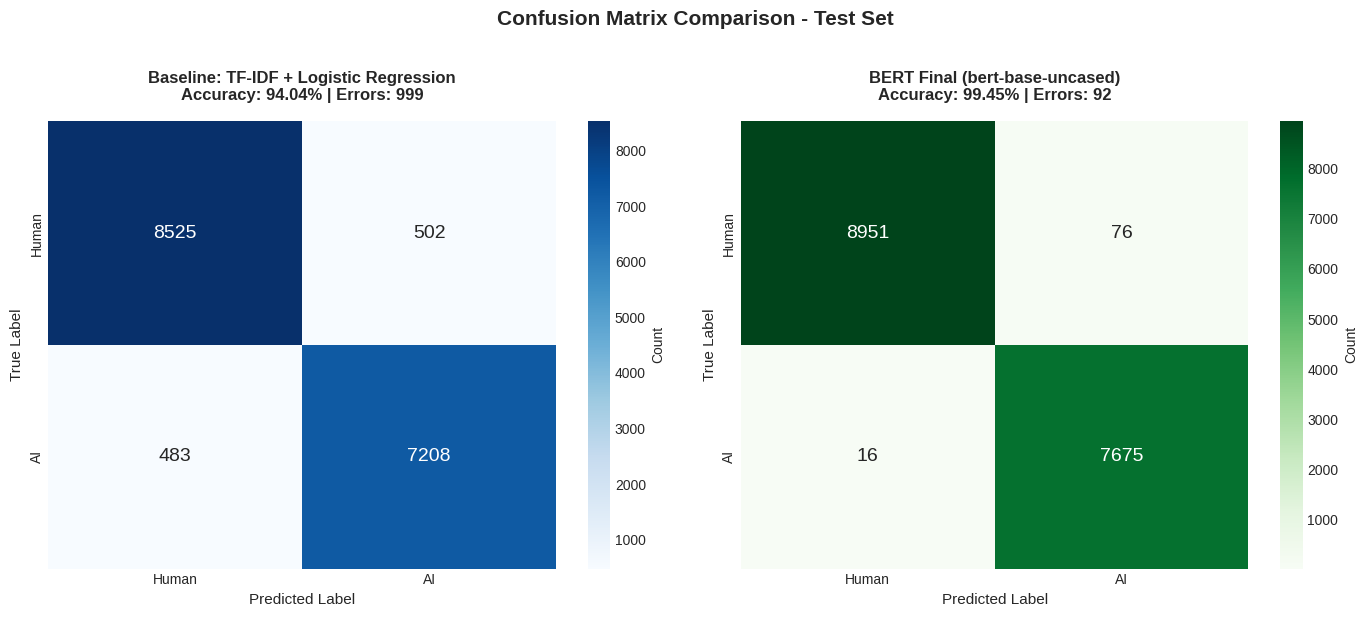


📊 Error Analysis Comparison:

Baseline:
   False Positives (Human→AI): 502 (5.56%)
   False Negatives (AI→Human): 483 (6.28%)

BERT Final:
   False Positives (Human→AI): 76 (0.84%)
   False Negatives (AI→Human): 16 (0.21%)

Improvement:
   FP reduction: 502 → 76 (84.9% fewer)
   FN reduction: 483 → 16 (96.7% fewer)


In [5]:
print("📊 Creating side-by-side confusion matrices...\n")

# Hardcoded confusion matrices from actual results
cm_baseline = np.array([
    [8525, 502],   # Human: TN, FP
    [483, 7208]    # AI: FN, TP
])

cm_bert_final = np.array([
    [8951, 76],    # Human: TN, FP
    [16, 7675]     # AI: FN, TP
])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Baseline confusion matrix
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Human', 'AI'],
            yticklabels=['Human', 'AI'],
            cbar_kws={'label': 'Count'},
            ax=axes[0], annot_kws={'size': 14})
axes[0].set_title('Baseline: TF-IDF + Logistic Regression\nAccuracy: 94.04% | Errors: 999',
                  fontsize=12, fontweight='bold', pad=15)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

# BERT Final confusion matrix
sns.heatmap(cm_bert_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Human', 'AI'],
            yticklabels=['Human', 'AI'],
            cbar_kws={'label': 'Count'},
            ax=axes[1], annot_kws={'size': 14})
axes[1].set_title('BERT Final (bert-base-uncased)\nAccuracy: 99.45% | Errors: 92',
                  fontsize=12, fontweight='bold', pad=15)
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontsize=11)

plt.suptitle('Confusion Matrix Comparison - Test Set',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/final_confusion_matrices.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/final_confusion_matrices.png")
plt.show()

print("\n📊 Error Analysis Comparison:")
print(f"\nBaseline:")
print(f"   False Positives (Human→AI): {cm_baseline[0,1]:,} ({cm_baseline[0,1]/cm_baseline[0].sum()*100:.2f}%)")
print(f"   False Negatives (AI→Human): {cm_baseline[1,0]:,} ({cm_baseline[1,0]/cm_baseline[1].sum()*100:.2f}%)")
print(f"\nBERT Final:")
print(f"   False Positives (Human→AI): {cm_bert_final[0,1]:,} ({cm_bert_final[0,1]/cm_bert_final[0].sum()*100:.2f}%)")
print(f"   False Negatives (AI→Human): {cm_bert_final[1,0]:,} ({cm_bert_final[1,0]/cm_bert_final[1].sum()*100:.2f}%)")
print(f"\nImprovement:")
print(f"   FP reduction: {cm_baseline[0,1]} → {cm_bert_final[0,1]} ({(1 - cm_bert_final[0,1]/cm_baseline[0,1])*100:.1f}% fewer)")
print(f"   FN reduction: {cm_baseline[1,0]} → {cm_bert_final[1,0]} ({(1 - cm_bert_final[1,0]/cm_baseline[1,0])*100:.1f}% fewer)")

📊 Creating training progression chart...

✅ Saved: results/training_progression.png


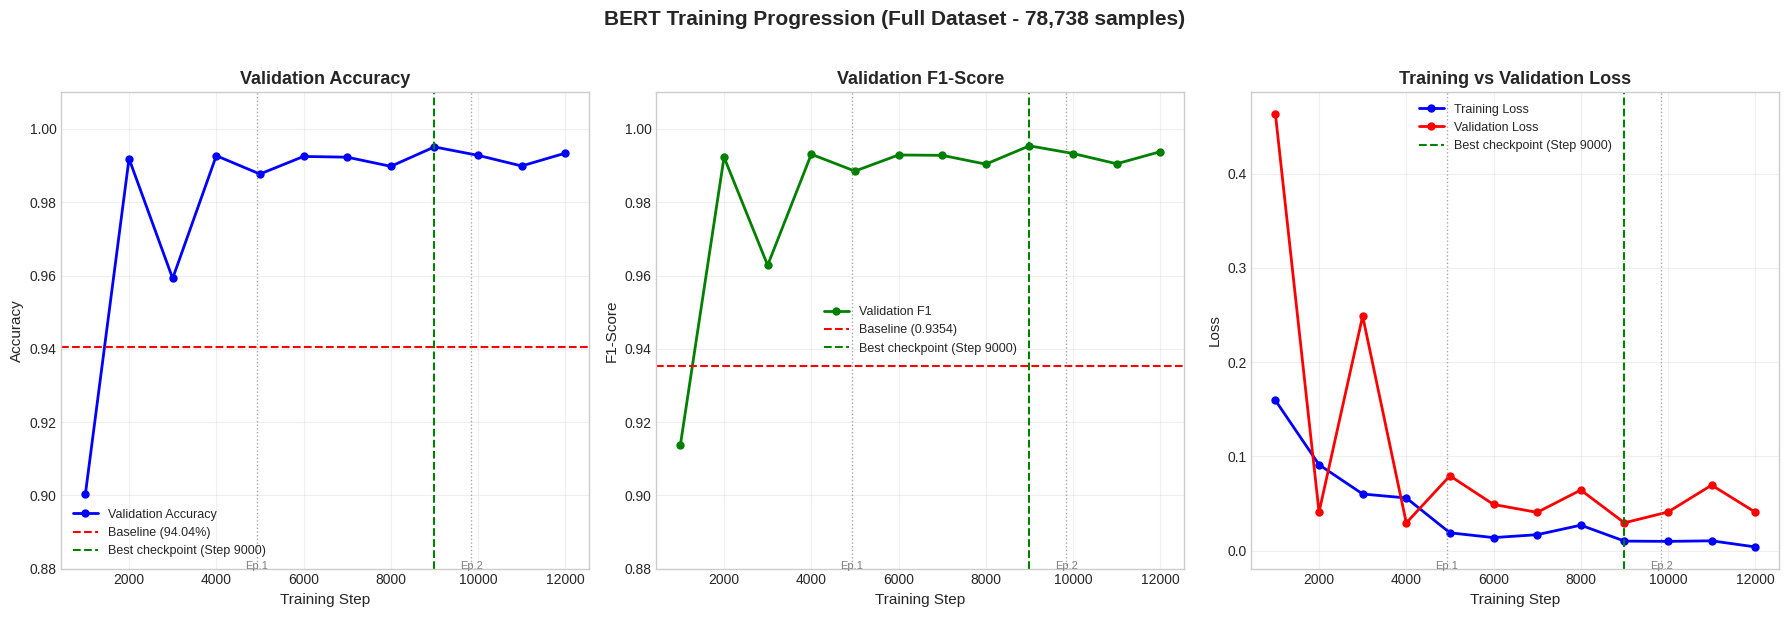

In [6]:
print("📊 Creating training progression chart...\n")

# Training history from actual logs
steps =     [1000,  2000,  3000,  4000,  5000,  6000,  7000,
             8000,  9000,  10000, 11000, 12000]
val_acc =   [0.9004, 0.9919, 0.9592, 0.9927, 0.9877, 0.9925, 0.9923,
             0.9898, 0.9951, 0.9928, 0.9899, 0.9934]
val_f1 =    [0.9138, 0.9923, 0.9628, 0.9931, 0.9885, 0.9929, 0.9928,
             0.9904, 0.9954, 0.9933, 0.9905, 0.9938]
val_loss =  [0.4634, 0.0408, 0.2489, 0.0293, 0.0793, 0.0489, 0.0405,
             0.0642, 0.0294, 0.0409, 0.0694, 0.0407]
train_loss =[0.1594, 0.0911, 0.0600, 0.0558, 0.0188, 0.0137, 0.0168,
             0.0269, 0.0100, 0.0097, 0.0103, 0.0038]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Accuracy progression
axes[0].plot(steps, val_acc, 'b-o', linewidth=2, markersize=5, label='Validation Accuracy')
axes[0].axhline(y=0.9404, color='red', linestyle='--', linewidth=1.5,
                label=f'Baseline (94.04%)')
axes[0].axvline(x=9000, color='green', linestyle='--', linewidth=1.5,
                label='Best checkpoint (Step 9000)')
axes[0].set_xlabel('Training Step', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Validation Accuracy', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_ylim([0.88, 1.01])
axes[0].grid(alpha=0.3)

# 2. F1-Score progression
axes[1].plot(steps, val_f1, 'g-o', linewidth=2, markersize=5, label='Validation F1')
axes[1].axhline(y=0.9354, color='red', linestyle='--', linewidth=1.5,
                label=f'Baseline (0.9354)')
axes[1].axvline(x=9000, color='green', linestyle='--', linewidth=1.5,
                label='Best checkpoint (Step 9000)')
axes[1].set_xlabel('Training Step', fontsize=11)
axes[1].set_ylabel('F1-Score', fontsize=11)
axes[1].set_title('Validation F1-Score', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_ylim([0.88, 1.01])
axes[1].grid(alpha=0.3)

# 3. Loss curves
axes[2].plot(steps, train_loss, 'b-o', linewidth=2, markersize=5, label='Training Loss')
axes[2].plot(steps, val_loss, 'r-o', linewidth=2, markersize=5, label='Validation Loss')
axes[2].axvline(x=9000, color='green', linestyle='--', linewidth=1.5,
                label='Best checkpoint (Step 9000)')
axes[2].set_xlabel('Training Step', fontsize=11)
axes[2].set_ylabel('Loss', fontsize=11)
axes[2].set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

# Add epoch markers
for ax in axes:
    ax.axvline(x=4922, color='gray', linestyle=':', linewidth=1, alpha=0.7)
    ax.axvline(x=9844, color='gray', linestyle=':', linewidth=1, alpha=0.7)
    ax.text(4922, ax.get_ylim()[0], 'Ep.1', ha='center', fontsize=8, color='gray')
    ax.text(9844, ax.get_ylim()[0], 'Ep.2', ha='center', fontsize=8, color='gray')

plt.suptitle('BERT Training Progression (Full Dataset - 78,738 samples)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/training_progression.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/training_progression.png")
plt.show()

In [7]:
print("=" * 70)
print("EVALUATION NOTEBOOK COMPLETE")
print("=" * 70)

print("\n📁 All Files Generated:")
results_files = [
    'results/complete_model_comparison.csv',
    'results/final_comparison_chart.png',
    'results/final_confusion_matrices.png',
    'results/training_progression.png',
    'results/baseline_metrics.json',
    'results/bert_final_metrics.json',
    'results/dataset_summary.csv',
    'results/class_distribution.png',
    'results/text_length_distribution.png',
    'results/word_clouds.png',
    'results/ultimate_comparison.png',
    'results/bert_final_confusion_matrix.png',
]

for f in results_files:
    status = "OK" if os.path.exists(f) else "MISSING"
    print(f"   [{status}] {f}")

print("\n" + "=" * 70)
print("PAPER-READY METRICS SUMMARY")
print("=" * 70)

print("""
DATASET:
   Total:     114,046 samples (57,023 human | 57,023 AI)
   Train:     78,738  |  Val: 18,590  |  Test: 16,718
   Sources:   HC3, gsingh, drcat
   Leakage:   ZERO (prompt-based splitting)

BASELINE - TF-IDF + Logistic Regression:
   Accuracy:  94.04%  Precision: 93.37%
   Recall:    93.71%  F1:        93.54%
   ROC-AUC:   98.68%  Errors:    999

BERT - bert-base-uncased (Final):
   Accuracy:  99.45%  Precision: 99.02%
   Recall:    99.79%  F1:        99.40%
   ROC-AUC:   99.97%  Errors:    92

IMPROVEMENT OVER BASELINE:
   Accuracy:  +5.41%
   F1-Score:  +5.86%
   Errors:    -90.8% (999 to 92)
""")

print("=" * 70)
print("READY FOR RESEARCH PAPER SUBMISSION!")
print("=" * 70)

EVALUATION NOTEBOOK COMPLETE

📁 All Files Generated:
   [OK] results/complete_model_comparison.csv
   [OK] results/final_comparison_chart.png
   [OK] results/final_confusion_matrices.png
   [OK] results/training_progression.png
   [OK] results/baseline_metrics.json
   [OK] results/bert_final_metrics.json
   [OK] results/dataset_summary.csv
   [OK] results/class_distribution.png
   [OK] results/text_length_distribution.png
   [OK] results/word_clouds.png
   [OK] results/ultimate_comparison.png
   [OK] results/bert_final_confusion_matrix.png

PAPER-READY METRICS SUMMARY

DATASET:
   Total:     114,046 samples (57,023 human | 57,023 AI)
   Train:     78,738  |  Val: 18,590  |  Test: 16,718
   Sources:   HC3, gsingh, drcat
   Leakage:   ZERO (prompt-based splitting)

BASELINE - TF-IDF + Logistic Regression:
   Accuracy:  94.04%  Precision: 93.37%
   Recall:    93.71%  F1:        93.54%
   ROC-AUC:   98.68%  Errors:    999

BERT - bert-base-uncased (Final):
   Accuracy:  99.45%  Precision: 